# Case Study 5: Spectral Anomaly Detection with a Keras Autoencoder
Train the autoencoder on normal spectra only, then flag high reconstruction-error samples.

<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-6/notebooks/05_autoencoder_anomaly_tensorflow_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



In [1]:
from pathlib import Path
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'anomaly_spectra.npz'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-6/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')
SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

def make_split(n, test_fraction=0.2):
    idx = np.arange(n)
    np.random.shuffle(idx)
    cut = int(n * (1 - test_fraction))
    return idx[:cut], idx[cut:]

def standardize(train, test, axis=0):
    mean = train.mean(axis=axis, keepdims=True)
    std = train.std(axis=axis, keepdims=True) + 1e-8
    return (train - mean) / std, (test - mean) / std, mean, std

def history_table(history):
    hist = pd.DataFrame(history.history)
    return hist.tail(5).round(4)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (8, 4.8),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10
})

def plot_history(history, metrics=None, title='Training history'):
    hist = pd.DataFrame(history.history)
    metrics = metrics or [c for c in hist.columns if not c.startswith('val_')]
    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        ax.plot(hist.index + 1, hist[metric], label=f'train {metric}', linewidth=2)
        val_metric = f'val_{metric}'
        if val_metric in hist:
            ax.plot(hist.index + 1, hist[val_metric], label=f'validation {metric}', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()
    fig.suptitle(title, y=1.03, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_binary_confusion(y_true, y_pred, labels, title='Confusion matrix'):
    cm = confusion_matrix(y_true.astype(int), y_pred.astype(int))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm


NumPy: 2.5.0
Pandas: 3.0.3
TensorFlow: 2.21.0
Keras: 3.15.0


In [2]:
data = np.load(DATA_DIR / 'anomaly_spectra.npz')
spectra = data['spectra'].astype('float32')
labels = data['labels'].astype(int)

normal_idx = np.where(labels == 0)[0]
anom_idx = np.where(labels == 1)[0]
np.random.shuffle(normal_idx)
train_normal = normal_idx[:430]
test_idx = np.concatenate([normal_idx[430:], anom_idx])

X_train_raw = spectra[train_normal]
X_test_raw = spectra[test_idx]
y_test = labels[test_idx]

X_train, X_test, mean, std = standardize(X_train_raw, X_test_raw, axis=0)
print('Normal-only training:', X_train.shape, 'Mixed test:', X_test.shape)
pd.Series(y_test).value_counts().rename(index={0: 'normal', 1: 'anomaly'})


Normal-only training: (430, 220) Mixed test: (270, 220)


anomaly    140
normal     130
Name: count, dtype: int64

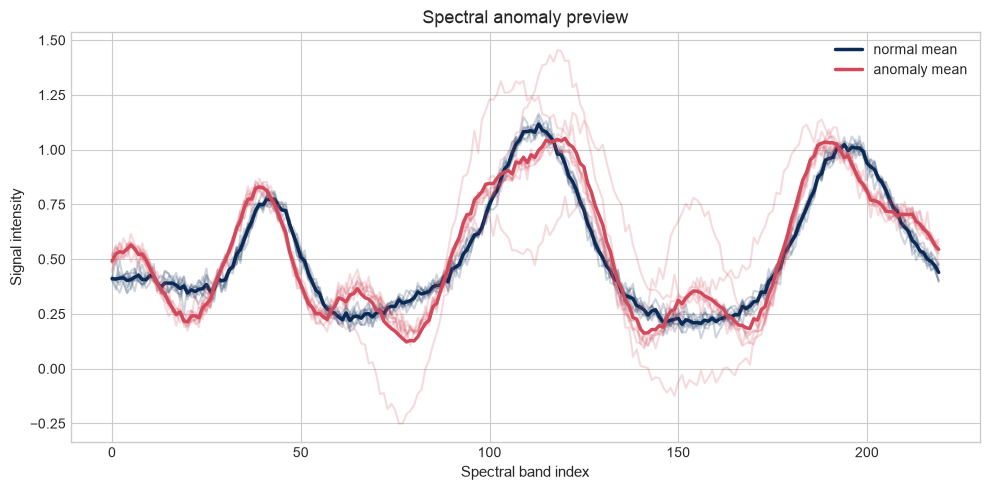

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for cls, color, name in [(0, '#0B2A55', 'normal'), (1, '#D1495B', 'anomaly')]:
    cls_idx = np.where(labels == cls)[0][:8]
    ax.plot(spectra[cls_idx].T, color=color, alpha=0.20)
    ax.plot(spectra[cls_idx].mean(axis=0), color=color, linewidth=2.5, label=f'{name} mean')
ax.set_title('Spectral anomaly preview')
ax.set_xlabel('Spectral band index')
ax.set_ylabel('Signal intensity')
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
input_dim = X_train.shape[1]
encoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(96, activation='relu'),
    layers.Dense(24, activation='relu'),
    layers.Dense(6, activation='linear', name='bottleneck')
], name='encoder')

decoder = keras.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(24, activation='relu'),
    layers.Dense(96, activation='relu'),
    layers.Dense(input_dim)
], name='decoder')

inputs = keras.Input(shape=(input_dim,))
reconstructions = decoder(encoder(inputs))
autoencoder = keras.Model(inputs, reconstructions, name='spectral_autoencoder')
autoencoder.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')
autoencoder.summary()


Model: "spectral_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 220)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 6)              │        23,694 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 220)            │        23,908 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,602 (185.95 KB)

 Trainable params: 47,602 (185.95 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = autoencoder.fit(
    X_train, X_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    verbose=0
)
history_table(history)


,loss,val_loss
25,0.8696,1.0048
26,0.8656,1.0051
27,0.8605,1.0057
28,0.8555,1.0073
29,0.8516,1.0086


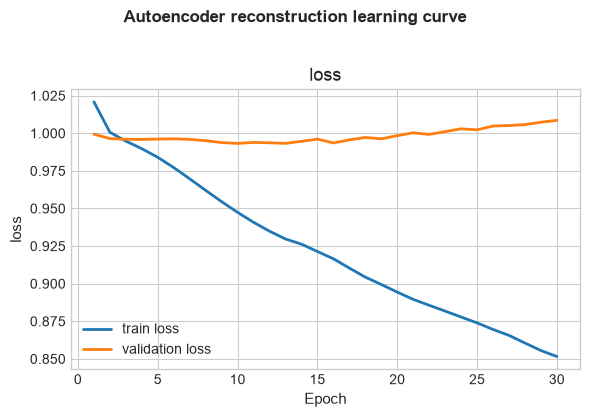

In [6]:
plot_history(history, metrics=['loss'], title='Autoencoder reconstruction learning curve')


In [7]:
train_recon = autoencoder.predict(X_train, verbose=0)
test_recon = autoencoder.predict(X_test, verbose=0)

train_err = np.mean((train_recon - X_train) ** 2, axis=1)
test_err = np.mean((test_recon - X_test) ** 2, axis=1)
threshold = np.quantile(train_err, 0.95)
pred_anomaly = (test_err > threshold).astype(int)

print(f'Reconstruction threshold: {threshold:.5f}')
print(f'Detection accuracy: {(pred_anomaly == y_test).mean():.3f}')
pd.DataFrame({
    'true_anomaly': y_test[:15],
    'reconstruction_error': test_err[:15],
    'flagged': pred_anomaly[:15]
}).round(5)


Reconstruction threshold: 1.08216
Detection accuracy: 0.874


,true_anomaly,reconstruction_error,flagged
0,0,1.05680,0
1,0,0.98405,0
2,0,0.91266,0
3,0,0.95872,0
4,0,1.18466,1
5,0,1.13942,1
6,0,0.98641,0
7,0,0.93703,0
8,0,0.95934,0
9,0,1.10430,1


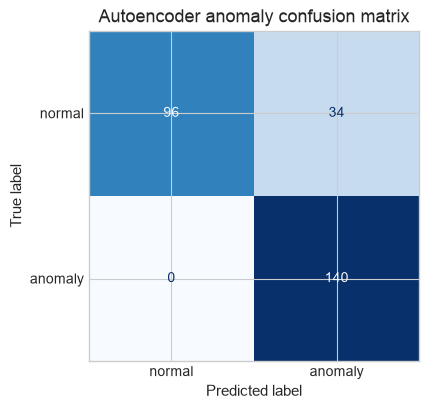

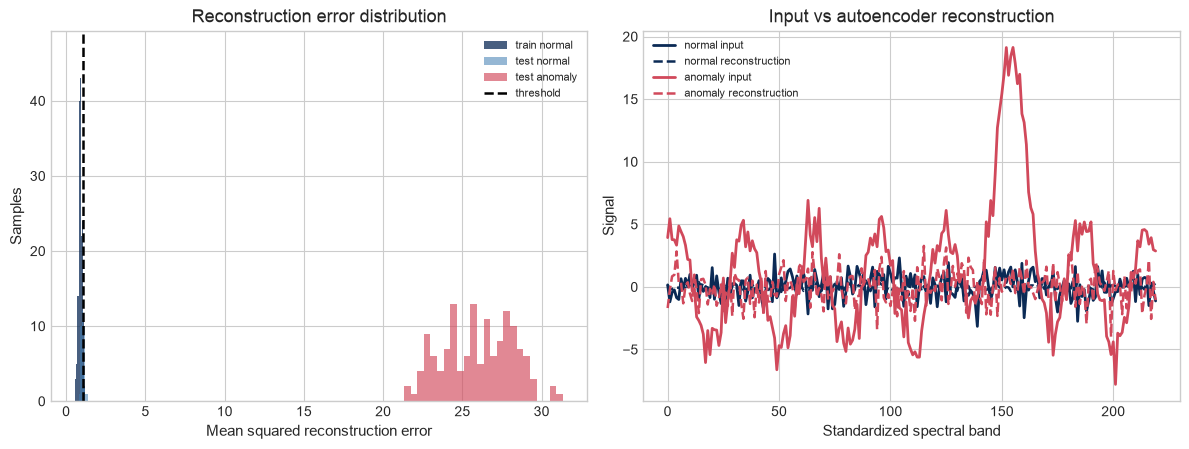

In [8]:
plot_binary_confusion(y_test, pred_anomaly, labels=['normal', 'anomaly'], title='Autoencoder anomaly confusion matrix')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(train_err, bins=24, alpha=0.75, label='train normal', color='#0B2A55')
axes[0].hist(test_err[y_test == 0], bins=24, alpha=0.55, label='test normal', color='#3E7CB1')
axes[0].hist(test_err[y_test == 1], bins=24, alpha=0.65, label='test anomaly', color='#D1495B')
axes[0].axvline(threshold, color='black', linestyle='--', linewidth=1.8, label='threshold')
axes[0].set_title('Reconstruction error distribution')
axes[0].set_xlabel('Mean squared reconstruction error')
axes[0].set_ylabel('Samples')
axes[0].legend(fontsize=8)

normal_example = np.where(y_test == 0)[0][0]
anomaly_example = np.where(y_test == 1)[0][0]
for idx, name, color in [(normal_example, 'normal', '#0B2A55'), (anomaly_example, 'anomaly', '#D1495B')]:
    axes[1].plot(X_test[idx], color=color, linewidth=2, label=f'{name} input')
    axes[1].plot(test_recon[idx], color=color, linestyle='--', linewidth=1.8, label=f'{name} reconstruction')
axes[1].set_title('Input vs autoencoder reconstruction')
axes[1].set_xlabel('Standardized spectral band')
axes[1].set_ylabel('Signal')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Teaching notes
- Threshold selection should be justified using normal validation samples.
- Anomaly detection flags unusual patterns; it does not identify the root cause by itself.
- Pair this with confirmatory chemistry or expert review.